## 12. K-Means++ Initialization

K-Means++ is an initialization algorithm for K-Means that helps to choose initial centroids that are far away from each other. This often leads to better and more consistent clustering results than random initialization.

The algorithm works as follows:
1.  Randomly select the first centroid from the data points.
2.  For each remaining data point, calculate its squared distance to the closest centroid already chosen.
3.  Select the next centroid from the remaining data points with a probability proportional to these squared distances (points farther away from existing centroids have a higher chance of being selected).
4.  Repeat steps 2 and 3 until K centroids have been chosen.

In [ ]:
def kmeans_plusplus_initializer(X, K):
    # Select the first centroid randomly
    centroids = [X[np.random.randint(X.shape[0])]]

    for _ in range(1, K):
        # Calculate squared distances from each point to its closest centroid
        distances = np.array([min([np.linalg.norm(point - c)**2 for c in centroids]) for point in X])

        # Choose the next centroid with probability proportional to distances
        probabilities = distances / distances.sum()
        next_centroid_idx = np.random.choice(X.shape[0], p=probabilities)
        centroids.append(X[next_centroid_idx])

    return np.array(centroids)


### Demonstrate K-Means++ Initialization

In [ ]:
# Use the K-Means++ initializer to get initial centroids
initial_centroids_plusplus = kmeans_plusplus_initializer(X, K)
print("Initial Centroids (K-Means++):\n", initial_centroids_plusplus)

# Run K-Means with the K-Means++ initialized centroids
final_centroids_plusplus, idx_plusplus = run_kmeans(X, initial_centroids_plusplus)

print("\nFinal Centroids (K-Means++):\n", final_centroids_plusplus)
print("\nFinal Cluster Assignments (K-Means++):\n", idx_plusplus)

cost_plusplus = compute_cost(X, idx_plusplus, final_centroids_plusplus)
print(f"\nFinal Cost (K-Means++): {cost_plusplus:.4f}")


Initial Centroids (K-Means++):
 [[3.5 5. ]
 [1.  1. ]
 [3.  4. ]
 [5.  7. ]
 [1.5 2. ]]


NameError: name 'run_kmeans' is not defined

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mitgandhi10/dataset-for-kmeans-clustering")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dataset-for-kmeans-clustering' dataset.
Path to dataset files: /kaggle/input/dataset-for-kmeans-clustering


In [ ]:
import os
import pandas as pd


In [ ]:
files = os.listdir(path)
print("files found",files)

files found ['Instagram visits clustering.csv']


In [ ]:
#!/bin/bash
!kaggle datasets download saquib7hussain/k-mean-cluster-dataset

Dataset URL: https://www.kaggle.com/datasets/saquib7hussain/k-mean-cluster-dataset
License(s): other
k-mean-cluster-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/k-mean-cluster-dataset.zip -d dataset_folder

Archive:  /content/k-mean-cluster-dataset.zip
replace dataset_folder/cluster_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: dataset_folder/cluster_data.csv  


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv(r"/content/dataset_folder/cluster_data.csv")
df.head()

,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


In [ ]:
m=len(df)

In [ ]:
K=4

In [ ]:
# Initial Centroids

indi = np.random.choice (len(df),K,replace=False)

initial_centroids = df.iloc[indi].to_numpy()
initial_centroids

array([[-1.30684233,  7.51791692],
       [-1.61895978,  6.88984422],
       [ 3.54975207, -1.17232137],
       [-0.91767902,  8.78470649]])

In [ ]:
centroids[0]

array([-0.91598298,  7.05372777])

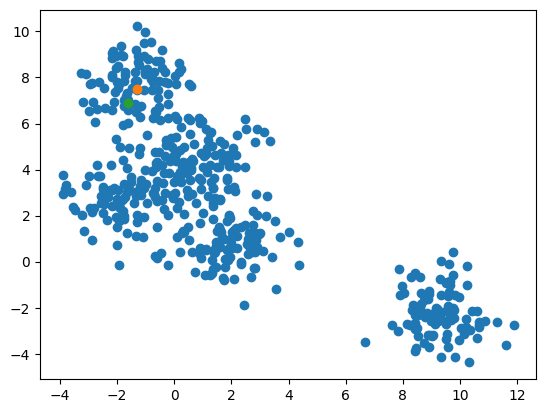

In [ ]:
plt.scatter(df.iloc[:,0],df.iloc[:,1])
plt.scatter(initial_centroids[0][0],initial_centroids[0][1])
plt.scatter(initial_centroids[1][0],initial_centroids[1][1])
plt.show()

In [ ]:
def closest_centroid(point,centroids):
  centroid =np.argmin(np.linalg.norm(centroids-point , axis=1))
  return centroid

#########################################################
def assign_centroids (df,centroids):
  idx =[]
  for point in df.to_numpy():
    idx.append(closest_centroid(point,centroids))
  return np.array(idx)

############################################################
def find_n_cen(df,idx , k):
    df=df.to_numpy()
    new_centroids = []

    for i in range(k):
      centroid = np.mean(df[idx==i],axis=0)
      new_centroids.append(centroid)

    return new_centroids

##################################################################
def compute_cost(X,idx,centroids):
  X=X.to_numpy()
  total = 0
  m=len(X)

  for i in range(m):
    centroid= centroids[idx[i]]
    total  += np.sum((X[i]-centroid)**2)
  return total/m

#####################################################################

def complete_kmeans(X,initial_centroids,max_iters=100):
  centroids=initial_centroids.copy()
  for i in range(max_iters):
    idx = assign_centroids(X,centroids)
    new_centroids = find_n_cen(X,idx,len(centroids))
    if np.allclose(new_centroids,centroids):
      break
    centroids=new_centroids
  return centroids,idx



In [ ]:
idx = assign_centroids(df,centroids)

In [ ]:
centroids

[array([-0.91598298,  7.05372777]),
 array([ 9.15403324, -0.98230514]),
 array([10.17614261, -2.87366388]),
 array([ 8.6970104, -2.65022  ]),
 array([0.42669889, 2.28195936])]

In [ ]:
new_centroids = find_n_cen(df,idx,k=2)

In [ ]:
compute_cost(df,idx,centroids)

np.float64(4.156967711670955)

In [ ]:
centroids

[array([-0.91598298,  7.05372777]),
 array([ 9.15403324, -0.98230514]),
 array([10.17614261, -2.87366388]),
 array([ 8.6970104, -2.65022  ]),
 array([0.42669889, 2.28195936])]

In [ ]:
new_centroids

[array([-0.91598298,  7.05372777]), array([ 9.15403324, -0.98230514])]

In [ ]:
final_centroids,idx = complete_kmeans(df,initial_centroids)
print(final_centroids)
print(idx)

[array([-0.47222146,  3.60693014]), array([1.85018446, 0.86350975]), array([ 9.30286933, -2.23802673]), array([-1.20119095,  7.65269328])]
[1 0 0 0 0 2 0 2 1 1 3 0 0 3 0 2 0 2 0 0 1 2 1 0 1 3 1 1 3 0 1 0 0 3 0 1 1
 2 2 2 3 2 0 1 0 0 2 0 1 3 0 2 1 1 2 0 2 2 3 0 1 2 1 0 0 3 0 3 0 0 0 1 0 2
 0 0 1 1 0 1 0 3 3 0 2 1 2 0 0 0 0 3 3 0 2 1 1 0 3 0 1 0 3 1 0 0 2 1 1 0 0
 0 1 2 2 3 3 3 1 2 2 0 0 3 0 0 2 0 3 3 3 1 0 2 3 2 2 2 0 0 1 3 1 0 1 2 2 3
 0 0 0 3 3 1 0 3 1 0 3 0 3 2 0 0 1 1 0 1 2 1 0 0 2 2 1 3 0 3 0 3 0 3 3 2 0
 2 1 0 3 2 3 1 2 0 1 0 0 2 3 3 1 3 0 3 3 1 2 0 0 0 2 3 0 3 2 3 2 1 1 1 1 0
 2 2 2 0 0 2 2 0 1 0 3 3 3 0 3 0 2 0 1 0 3 2 1 1 3 3 1 2 2 0 1 1 0 0 1 0 0
 3 2 0 3 1 0 0 2 1 0 1 0 3 0 1 3 1 3 1 3 3 0 1 1 1 0 1 3 0 3 2 0 1 3 0 1 2
 3 0 2 3 2 1 1 1 3 0 2 1 1 3 2 3 0 2 0 0 0 2 2 2 3 3 0 1 0 3 2 2 1 1 3 0 1
 0 0 0 0 3 0 2 0 3 0 2 1 1 1 3 0 1 0 1 0 0 0 1 0 0 0 2 0 0 2 0 0 1 0 1 3 3
 1 0 2 0 1 1 2 0 3 0 2 2 0 2 2 3 3 2 0 3 3 3 0 2 2 2 2 1 3 1 0 0 2 1 1 0 0
 0 0 3 2 0 2 3 1 0 2 3 0 1 2 0 3 0 1

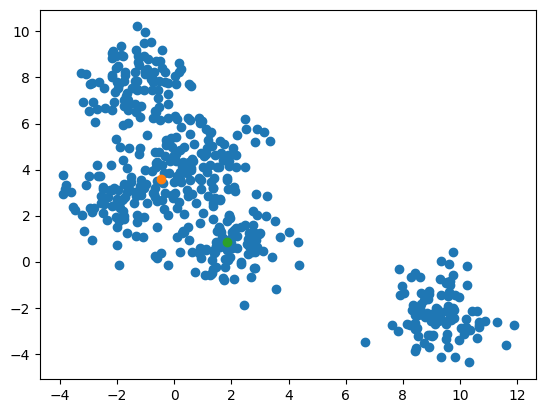

In [ ]:
from typing_extensions import final
plt.scatter(df.iloc[:,0],df.iloc[:,1])
plt.scatter(final_centroids[0][0],final_centroids[0][1])
plt.scatter(final_centroids[1][0],final_centroids[1][1])
plt.show()

In [ ]:
costs =[]

for K in range(2,6):
  random_indices = np.random.choice(len(df),K,replace=False)
  initial= df.iloc[random_indices]
  centroids,idx = complete_kmeans(df,initial,200)
  cost = compute_cost(df,idx,centroids)
  costs.append(cost)

In [ ]:
random_indices

array([266, 497, 452, 222,  85])

In [ ]:
len(df)

500

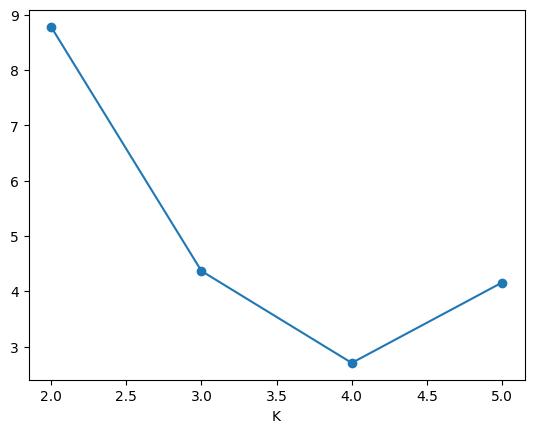

In [ ]:
plt.plot(range(2,6),costs,marker='o')
plt.xlabel("K")
plt.show()